In [4]:
! uv pip install -r requirements.txt

Resolved 22 packages in 223ms                                        
⠙ Preparing packages... (0/3)                                                   
⠙ Preparing packages... (0/3)-------------------     0 B/25.81 KiB           
⠙ Preparing packages... (0/3)0m------------- 14.89 KiB/25.81 KiB         
⠙ Preparing packages... (0/3)---------- 25.81 KiB/25.81 KiB         
⠙ Preparing packages... (0/3)---------- 25.81 KiB/25.81 KiB         
filelock             ------------------------------ 25.81 KiB/25.81 KiB
⠙ Preparing packages... (0/3)-------------------     0 B/4.44 MiB            
filelock             ------------------------------ 25.81 KiB/25.81 KiB
⠙ Preparing packages... (0/3)-------------------     0 B/4.44 MiB            
⠙ Preparing packages... (0/3)-------------------     0 B/4.44 MiB            
⠙ Preparing packages... (0/3)------------------- 14.92 KiB/4.44 MiB          
⠙ Preparing packages... (0/3)------------------- 30.92 KiB/4.44 MiB          
⠙ Preparing packages... (

# Convolutional Neural Networks (CNN) — Class 1

This notebook introduces:
1. **Custom CNN**: A small convolutional network and how an image is transformed layer by layer.
2. **ResNet50**: A modern architecture with skip connections and how it works.

We use **PyTorch** for implementation and **matplotlib** for visualization.

> **Dependencies:** `pip install torch torchvision matplotlib`

---
## 1. Setup and imports

We need:
- **torch** and **torch.nn**: define and run the CNN.
- **torchvision**: load a sample image and the pre-trained ResNet50 model.
- **matplotlib**: plot the original image and the feature maps (activations) after each layer.

In [5]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from torchvision import transforms
from torchvision.io import read_image
from pathlib import Path

# Use CPU for simplicity (change to "cuda" if you have a GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


### 1.1 Load a sample image

We load one image and normalize it to the range expected by typical CNNs. The tensor shape is **(batch, channels, height, width)** = (1, 3, H, W). We use a small crop/resize so feature maps remain interpretable.

/Users/earevalo/Workspace/fceia/CNN/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


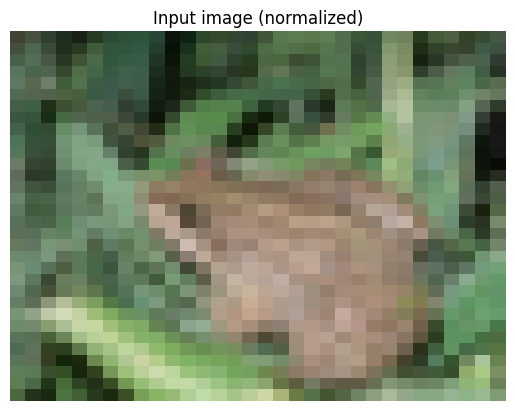

Input shape: torch.Size([1, 3, 64, 64])  (batch, channels, height, width)


In [ ]:
# Option A: Use one image from CIFAR-10 (downloads once)
from torchvision.datasets import CIFAR10

cifar = CIFAR10(root="./data", download=True, train=False)
img_pil = cifar[0][0]  # PIL Image — CIFAR-10 is native 32×32
img_size = 32  # CIFAR-10 native size

transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
x = transform(img_pil).unsqueeze(0).to(device)  # (1, 3, 32, 32)

# Show original image (denormalize for display) at 32×32
def denorm(t):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(t.device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(t.device)
    return t * std + mean


plt.figure(figsize=(3.2, 3.2))
plt.imshow(denorm(x).squeeze(0).permute(1, 2, 0).cpu().numpy().clip(0, 1))
plt.axis("off")
plt.title("Input image (32×32, CIFAR-10)")
plt.show()
print(f"Input shape: {x.shape}  (batch, channels, height, width)")

---
## 2. Custom Convolutional Neural Network

We define a **small CNN** with several blocks. Each block contains:
- **Conv2d**: learns local patterns (edges, textures) via kernels. Output has multiple *channels* (feature maps).
- **ReLU**: non-linearity so the network can approximate complex functions.
- **MaxPool2d**: downsamples the spatial dimensions, making the representation more compact and invariant to small shifts.

The **output size** after each layer can be computed from:  
`out_size = (in_size + 2*padding - kernel_size) / stride + 1`  
(For max pool, same formula with kernel and stride of the pool.)

In [ ]:
class CustomCNN(nn.Module):
    """Simple CNN: Conv -> ReLU -> Pool repeated, then flatten and classify."""

    def __init__(self):
        super().__init__()
        # Block 1: 3 -> 16 channels, spatial size reduced by pool
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)   # (1, 3, 32, 32) -> (1, 16, 32, 32)
        self.pool1 = nn.MaxPool2d(2, 2)                            # -> (1, 16, 16, 16)

        # Block 2: 16 -> 32 channels
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)  # -> (1, 32, 16, 16)
        self.pool2 = nn.MaxPool2d(2, 2)                            # -> (1, 32, 8, 8)

        # Block 3: 32 -> 64 channels
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # -> (1, 64, 8, 8)
        self.pool3 = nn.MaxPool2d(2, 2)                            # -> (1, 64, 4, 4)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.pool3(self.relu(self.conv3(x)))
        return x

model = CustomCNN().to(device)
model.eval()

### 2.1 Capturing activations with hooks

To **visualize how the image is transformed after each layer**, we register **forward hooks** on the model. Each hook is a function that PyTorch calls after a layer runs, so we can store that layer’s output (the *activations* or *feature maps*). We store outputs after: Conv1+ReLU, Pool1, Conv2+ReLU, Pool2, Conv3+ReLU, Pool3.

In [ ]:
activations = {}

def get_activation(name):
    def hook(module, input, output):
        activations[name] = output.detach()
    return hook

# Register hooks on the layers we want to visualize (after each block: conv+relu then pool)
model.conv1.register_forward_hook(get_activation("after_conv1_relu"))
model.pool1.register_forward_hook(get_activation("after_pool1"))
model.conv2.register_forward_hook(get_activation("after_conv2_relu"))
model.pool2.register_forward_hook(get_activation("after_pool2"))
model.conv3.register_forward_hook(get_activation("after_conv3_relu"))
model.pool3.register_forward_hook(get_activation("after_pool3"))

# Forward pass: this fills `activations`
_ = model(x)

### 2.2 Visualizing the feature maps after each layer

Each **channel** of the activation tensor is a 2D *feature map*: the response of one filter over the spatial dimensions. Early layers often capture edges and simple textures; deeper layers capture more abstract patterns. We plot a grid of channels for each captured layer (only a subset of channels if there are many).

In [ ]:
def show_feature_maps(activations_dict, max_channels=16, figsize_per_block=(12, 3)):
    """Plot feature maps for each stored layer. Each row = one layer, each column = one channel."""
    layer_names = [
        "after_conv1_relu", "after_pool1",
        "after_conv2_relu", "after_pool2",
        "after_conv3_relu", "after_pool3",
    ]
    for name in layer_names:
        if name not in activations_dict:
            continue
        feat = activations_dict[name]  # (1, C, H, W)
        C, H, W = feat.shape[1], feat.shape[2], feat.shape[3]
        n_show = min(max_channels, C)
        fig, axes = plt.subplots(1, n_show, figsize=figsize_per_block)
        if n_show == 1:
            axes = [axes]
        for i in range(n_show):
            im = feat[0, i].cpu().numpy()
            axes[i].imshow(im, cmap="viridis")
            axes[i].set_title(f"ch {i}")
            axes[i].axis("off")
        plt.suptitle(f"{name}  shape: (1, {C}, {H}, {W})")
        plt.tight_layout()
        plt.show()

show_feature_maps(activations)

---
## 3. ResNet50: residual networks and why they work

### 3.1 The vanishing gradient problem

In **very deep** networks (many layers), gradients can become very small as they are backpropagated. As a result, early layers learn slowly or almost not at all. This limits how deep we can train networks effectively.

### 3.2 Skip connections (residual connections)

**ResNet** (He et al., 2015) introduces **skip connections**: the input to a block is added to the output of the block before passing to the next layer:

$$y = F(x) + x$$

- **x**: input to the block  
- **F(x)**: output of the convolutional layers inside the block  
- **y**: we learn the *residual* (the change) instead of the full mapping

This way, the gradient can flow directly through the identity path ($x$), so it does not vanish. The network can learn to make $F(x)$ small when no change is needed, effectively using more or fewer layers as needed.

### 3.3 ResNet50 architecture in short

- **50** refers to roughly 50 *weight layers* (conv + fc).
- **Stem**: one conv + max pool that reduce spatial size and increase channels.
- **Stages**: four stages, each made of several **bottleneck blocks**.
- **Bottleneck block**: 1×1 conv (reduce channels) → 3×3 conv → 1×1 conv (restore channels), plus a skip connection. The 1×1 convolutions make the block cheaper in parameters and compute.
- **Global average pool** then a **fully connected** layer for classification.

So ResNet50 is a deep CNN that stays trainable thanks to residual (skip) connections and uses bottleneck blocks for efficiency.

### 3.4 Bottleneck block (code)

A **bottleneck block** in ResNet looks like this:  
`1×1 conv (reduce C) → 3×3 conv → 1×1 conv (restore C)` and then **add the input** (skip). The 1×1 convolutions reduce and then restore the number of channels, so the 3×3 conv works on fewer channels and the block is cheaper.

In [ ]:
class BottleneckBlock(nn.Module):
    """One ResNet bottleneck: 1x1 -> 3x3 -> 1x1 conv + skip connection."""

    def __init__(self, in_ch, mid_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, mid_ch, 1, stride=1, bias=False)
        self.conv2 = nn.Conv2d(mid_ch, mid_ch, 3, stride=stride, padding=1, bias=False)
        self.conv3 = nn.Conv2d(mid_ch, out_ch, 1, bias=False)
        self.relu = nn.ReLU(inplace=True)
        # If spatial size or channels change, we need to project the skip to match
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False)
            )

    def forward(self, x):
        identity = x
        out = self.relu(self.conv1(x))
        out = self.relu(self.conv2(out))
        out = self.conv3(out)
        out = out + self.shortcut(identity)  # skip connection
        out = self.relu(out)
        return out

# Example: 256 -> 64 -> 64 -> 256 channels, same spatial size
block = BottleneckBlock(256, 64, 256)
dummy = torch.randn(1, 256, 32, 32)
print("Bottleneck block output shape:", block(dummy).shape)

### 3.5 Using pre-trained ResNet50

We load **ResNet50** from `torchvision.models` (pre-trained on ImageNet) and run a forward pass. The model expects input of size **224×224**. We use the same normalization (ImageNet mean/std) as before.

In [ ]:
from torchvision.models import resnet50, ResNet50_Weights

# Load pre-trained ResNet50
weights = ResNet50_Weights.IMAGENET1K_V1
resnet = resnet50(weights=weights).to(device)
resnet.eval()

# ResNet expects 224x224; resize our image
transform_224 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
x_224 = transform_224(img_pil).unsqueeze(0).to(device)

with torch.no_grad():
    logits = resnet(x_224)

probs = torch.softmax(logits, dim=1)
top5_prob, top5_idx = torch.topk(probs[0], 5)
print("ResNet50 top-5 predictions (ImageNet):")
for i in range(5):
    print(f"  {i+1}. class index {top5_idx[i].item():3d}  prob = {top5_prob[i].item():.4f}")

### 3.6 ResNet50 layer overview

ResNet50 is built from a **stem** (conv + bn + relu + maxpool) and **4 stages** of bottleneck blocks. The following lists the main submodules so you can see how the 50 layers are organized.

In [ ]:
# Inspect ResNet50 structure
for name, child in resnet.named_children():
    n_params = sum(p.numel() for p in child.parameters())
    print(f"{name:12s}  parameters: {n_params:>10,}")

---
## Summary

| Topic | Takeaway |
|--------|----------|
| **Custom CNN** | Convolutions extract local features; pooling reduces size; we can hook layers to visualize feature maps after each step. |
| **ResNet50** | Uses **skip connections** so gradients flow and deep networks train well; **bottleneck blocks** (1×1–3×3–1×1) keep it efficient; ~50 weight layers, four stages, then global pool and classifier. |